# Test Model and Atlas Inititiation

## Setup

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.atlas import StaticGaussianAtlas
from aligner.inventory import SliceAtlas
from aligner.matcher import HungarianMatcher 

## Atlas Load

In [39]:
# Initialize the libraries
gauss_atlas = StaticGaussianAtlas("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv")
slice_db = SliceAtlas("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv")



In [49]:
# Test 1: Check slice retrieval for an 8-cell embryo
n_obs = 6
candidates = slice_db.get_candidates(n_obs)
print(f"Found {len(candidates)} biological hypotheses for {n_obs} cells.")

candidates

Found 1 biological hypotheses for 6 cells.


[('ABal', 'ABar', 'ABpl', 'ABpr', 'EMS', 'P2')]

In [50]:
# Test 2: Verify the Gaussian lookup for the first candidate
sample_labels = candidates[0]
ref_mus, ref_invs = gauss_atlas.get_params(list(sample_labels))
print(f"Successfully retrieved {len(ref_mus)} means from the Gaussian Atlas.")

ref_mus
ref_invs

Successfully retrieved 6 means from the Gaussian Atlas.


[array([[106.01212615, -47.23509388,  71.83733171],
        [-47.23509388, 280.54934245,  77.61154764],
        [ 71.83733171,  77.61154764, 335.99743047]]),
 array([[ 233.54526076, -133.98220825,  177.25016177],
        [-133.98220825,  108.05324393,  -89.84238071],
        [ 177.25016177,  -89.84238071,  250.8848418 ]]),
 array([[ 234.47433636, -135.54252506,   57.74448431],
        [-135.54252506,   94.79040893,  -53.11649824],
        [  57.74448431,  -53.11649824,  113.14193178]]),
 array([[119.67712608, -38.62397671, -47.16068174],
        [-38.62397671, 185.82421627,  64.83716023],
        [-47.16068174,  64.83716023, 101.93213013]]),
 array([[ 349.22562733, -134.14777571,   25.56032662],
        [-134.14777571,  212.84252465,  -79.45560774],
        [  25.56032662,  -79.45560774,  144.63794128]]),
 array([[257.89635606, -27.38784029, 127.00411961],
        [-27.38784029, 105.57004574, -25.12638242],
        [127.00411961, -25.12638242, 569.61688692]])]

In [51]:
# Create the schematic model for the first hypothesis
hypothetical_embryo = ReferenceFrame(sample_labels, gauss_atlas)

print(f"Labels: {hypothetical_embryo.labels[:4]}...")
print(f"Centered Means Shape: {hypothetical_embryo.centered_means.shape}")
print(f"Principal Axis (PC1): {hypothetical_embryo.pc1_axis}")

# Sanity Check: The center of mass should be at [0, 0, 0]
com = hypothetical_embryo.centered_means.mean(axis=0)
print(f"Center of Mass: {com}") # Should be near zero

Labels: ('ABal', 'ABar', 'ABpl', 'ABpr')...
Centered Means Shape: (6, 3)
Principal Axis (PC1): [-0.98384916  0.16260285 -0.0748408 ]
Center of Mass: [-2.40548322e-16  3.70074342e-17  1.48029737e-16]


## Embryo Test

In [52]:
# Let's just use the reference means + some noise and a shift
raw_coords = ref_mus * 1.2 + np.random.normal(0, 5, size=ref_mus.shape) + 100

# Initialize the Model
frame = EmbryoFrame(coords=raw_coords, embryo_id="TEST_01", time_idx=1)

print(f"Before Prepare: Mean = {frame.coords.mean(axis=0)}")
print(f"Before Prepare: Scale = {frame.scale_factor}")

# Run the logic we wrote
frame.prepare()

print(f"After Prepare: Mean = {frame.normalized_coords.mean(axis=0)}") # Should be near [0,0,0]
print(f"After Prepare: Scale = {frame.scale_factor}")

frame

Before Prepare: Mean = [ 99.90600793 104.19052456 100.92712303]
Before Prepare: Scale = 1.0
After Prepare: Mean = [ 5.92118946e-16  5.92118946e-16 -1.03620816e-15]
After Prepare: Scale = 11.798428215179218


EmbryoFrame(ID=TEST_01, T=1, N=6)

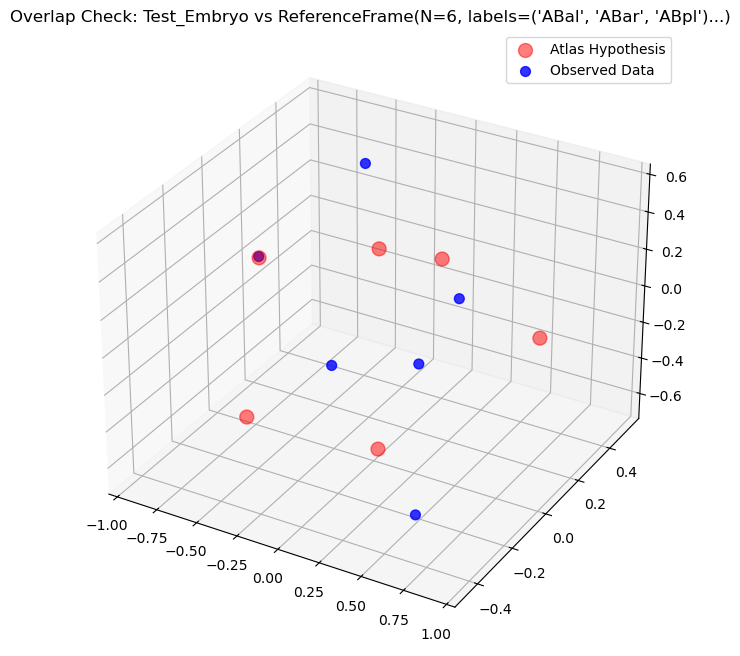

In [62]:

# Initialize and prepare your observed data
obs_frame = EmbryoFrame(raw_coords, "Test_Embryo", 1)
obs_frame.prepare()

# Plot them together
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Schematic (Red)
ax.scatter(hypothetical_embryo.centered_means[:, 0], 
           hypothetical_embryo.centered_means[:, 1], 
           hypothetical_embryo.centered_means[:, 2], 
           color='red', s=100, label='Atlas Hypothesis', alpha=0.5)

# Plot Observed (Blue)
ax.scatter(obs_frame.normalized_coords[:, 0], 
           obs_frame.normalized_coords[:, 1], 
           obs_frame.normalized_coords[:, 2], 
           color='blue', s=50, label='Observed Data', alpha=0.8)

ax.set_title(f"Overlap Check: {obs_frame.embryo_id} vs {hypothetical_embryo}")
ax.legend()
plt.show()

In [57]:
obs_frame


EmbryoFrame(ID=Test_Embryo, T=1, N=6)

In [58]:
hypothetical_embryo

ReferenceFrame(N=6, labels=('ABal', 'ABar', 'ABpl')...)

In [59]:
obs_frame.normalized_coords

array([[ 0.62167979, -0.10711199,  0.39165372],
       [ 0.33946125, -0.06087513, -0.06347126],
       [-0.33276757,  0.06450438, -0.35446946],
       [ 0.53341146, -0.25830458, -0.65378709],
       [-0.35844222,  0.28281209,  0.56486769],
       [-0.8033427 ,  0.07897523,  0.1152064 ]])

In [63]:
hypothetical_embryo.centered_means

array([[ 9.14935445e-01,  7.36483526e-02,  1.10016922e-01],
       [ 5.22889827e-01, -4.56114299e-01, -1.19608620e-01],
       [ 3.11465954e-03,  2.83235798e-02,  3.91604855e-01],
       [-3.93346111e-01, -3.43818528e-01, -2.99549878e-01],
       [-1.27044723e-01,  5.18741475e-01, -8.28202635e-02],
       [-9.20549097e-01,  1.79219419e-01,  3.56983077e-04]])

In [68]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from typing import Tuple
coords_a = obs_frame.normalized_coords
coords_b = hypothetical_embryo.centered_means

C = cdist(coords_a, coords_b, metric = "sqeuclidean")

out = linear_sum_assignment(C)
out

(array([0, 1, 2, 3, 4, 5]), array([0, 4, 3, 1, 2, 5]))

In [69]:
from aligner.matcher import HungarianMatcher

# 1. Setup
matcher = HungarianMatcher()
obs_pts = frame.normalized_coords
ref_pts = hypothetical_embryo.centered_means

# 2. Run Matcher
row_idx, col_idx = matcher.match(obs_pts, ref_pts)

# 3. Verify
for i in range(len(row_idx)):
    print(f"Observed Cell {row_idx[i]} matched to Atlas Label: {hypothetical_embryo.labels[col_idx[i]]}")

Observed Cell 0 matched to Atlas Label: ABal
Observed Cell 1 matched to Atlas Label: EMS
Observed Cell 2 matched to Atlas Label: ABpr
Observed Cell 3 matched to Atlas Label: ABar
Observed Cell 4 matched to Atlas Label: ABpl
Observed Cell 5 matched to Atlas Label: P2


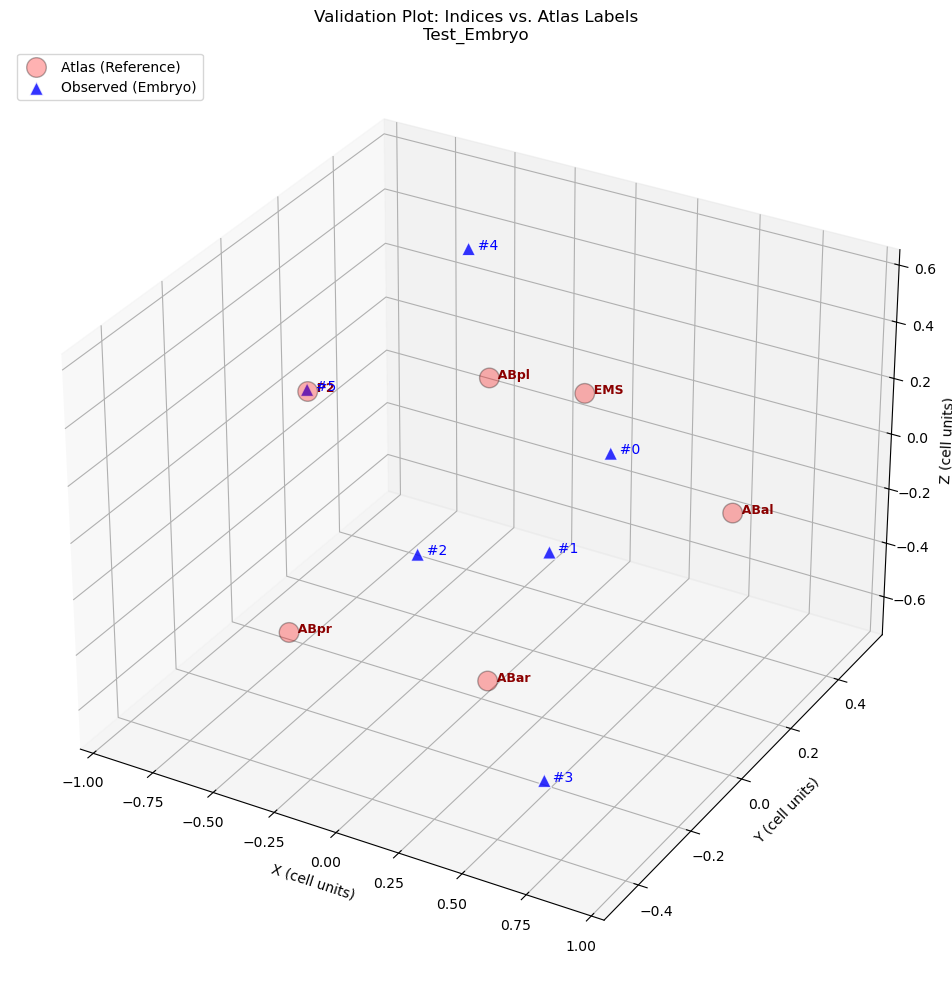

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot Atlas (Schematic Reference)
# Using circles 'o' as the reference points
atlas_pts = hypothetical_embryo.centered_means
atlas_labels = hypothetical_embryo.labels

ax.scatter(atlas_pts[:, 0], atlas_pts[:, 1], atlas_pts[:, 2], 
           color='red', marker='o', s=200, edgecolors='black', 
           alpha=0.3, label='Atlas (Reference)')

# Add biological names next to Atlas points
for i, name in enumerate(atlas_labels):
    ax.text(atlas_pts[i, 0], atlas_pts[i, 1], atlas_pts[i, 2], 
            f"  {name}", color='darkred', fontsize=9, fontweight='bold')

# 3. Plot Observed Data (Experimental)
# Using triangles '^' as the experimental points
obs_pts = obs_frame.normalized_coords #@ R

ax.scatter(obs_pts[:, 0], obs_pts[:, 1], obs_pts[:, 2], 
           color='blue', marker='^', s=100, edgecolors='white', 
           alpha=0.8, label='Observed (Embryo)')

# Add numerical indices next to Observed points
for i in range(len(obs_pts)):
    ax.text(obs_pts[i, 0], obs_pts[i, 1], obs_pts[i, 2], 
            f"  #{i}", color='blue', fontsize=10)

# 4. Final touches
ax.set_title(f"Validation Plot: Indices vs. Atlas Labels\n{obs_frame.embryo_id}")
ax.set_xlabel('X (cell units)')
ax.set_ylabel('Y (cell units)')
ax.set_zlabel('Z (cell units)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

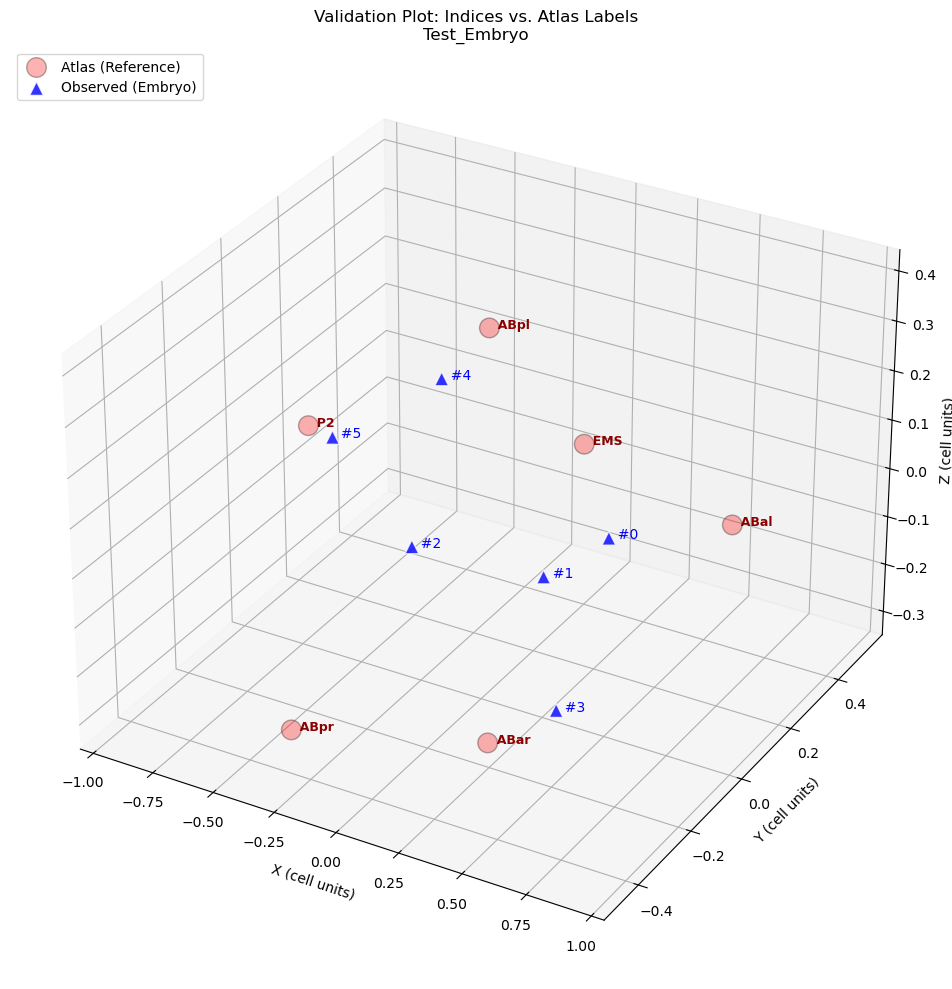

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot Atlas (Schematic Reference)
# Using circles 'o' as the reference points
atlas_pts = hypothetical_embryo.centered_means #@ R
atlas_labels = hypothetical_embryo.labels

ax.scatter(atlas_pts[:, 0], atlas_pts[:, 1], atlas_pts[:, 2], 
           color='red', marker='o', s=200, edgecolors='black', 
           alpha=0.3, label='Atlas (Reference)')

# Add biological names next to Atlas points
for i, name in enumerate(atlas_labels):
    ax.text(atlas_pts[i, 0], atlas_pts[i, 1], atlas_pts[i, 2], 
            f"  {name}", color='darkred', fontsize=9, fontweight='bold')

# 3. Plot Observed Data (Experimental)
# Using triangles '^' as the experimental points
obs_pts = obs_frame.normalized_coords @ R

ax.scatter(obs_pts[:, 0], obs_pts[:, 1], obs_pts[:, 2], 
           color='blue', marker='^', s=100, edgecolors='white', 
           alpha=0.8, label='Observed (Embryo)')

# Add numerical indices next to Observed points
for i in range(len(obs_pts)):
    ax.text(obs_pts[i, 0], obs_pts[i, 1], obs_pts[i, 2], 
            f"  #{i}", color='blue', fontsize=10)

# 4. Final touches
ax.set_title(f"Validation Plot: Indices vs. Atlas Labels\n{obs_frame.embryo_id}")
ax.set_xlabel('X (cell units)')
ax.set_ylabel('Y (cell units)')
ax.set_zlabel('Z (cell units)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
ccv = obs_pts.T @ ref_pts
#ccv

U, S, Vh = np.linalg.svd(ccv)

In [83]:
U


array([[-0.98382855,  0.02762367, -0.17696983],
       [ 0.16368023, -0.26256068, -0.95093147],
       [-0.07273354, -0.96452   ,  0.25379325]])

In [84]:
Vh

array([[-0.89669055,  0.41377514,  0.1572774 ],
       [-0.43286168, -0.89396826, -0.11598068],
       [-0.09261108,  0.17207814, -0.9807203 ]])

In [88]:
np.linalg.det(Vh.T @ U.T)

np.float64(0.9999999999999999)

In [86]:
Vh[-1, :] *= -1

In [87]:
Vh

array([[-0.89669055,  0.41377514,  0.1572774 ],
       [-0.43286168, -0.89396826, -0.11598068],
       [ 0.09261108, -0.17207814,  0.9807203 ]])

In [89]:
R = Vh.T * U.T

In [90]:
R

array([[ 0.88218977, -0.0708509 , -0.00673593],
       [ 0.01142999,  0.23472091,  0.16597281],
       [-0.02783335,  0.11028968,  0.24890019]])

In [101]:
from aligner.transformer import RigidTransformer
import numpy as np

# Create a small "Toy" point cloud (a 3D L-shape)
# This makes it easy to see if the orientation is correct
source_pts = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 2, 0],
    [0, 0, 3]
], dtype=float)

tx = RigidTransformer()

In [102]:
# 1. Generate 90-degree rotation matrix around Z-axis [0, 0, 1]
angle = np.radians(90)
axis = np.array([0, 0, 1])
R_90 = RigidTransformer.get_rotation_about_axis(axis, angle)

# 2. Apply it
rotated_pts = source_pts @ R_90

print("Original [1, 0, 0] point:")
print(source_pts[1])
print("\nAfter 90 deg rotation around Z (should be [0, 1, 0]):")
print(np.round(rotated_pts[1], 2))

Original [1, 0, 0] point:
[1. 0. 0.]

After 90 deg rotation around Z (should be [0, 1, 0]):
[0. 1. 0.]


In [103]:
# 1. Create a "Target" by moving the rotated points far away
translation = np.array([10, -5, 20])
target_pts = rotated_pts + translation

# 2. Tell the transformer to find the math that links source to target
tx.fit(source_pts, target_pts)

# 3. Transform the source and see if it overlaps with target
recovered_pts = tx.transform(source_pts)

# 4. Check the Error
rmsd = np.sqrt(np.mean(np.square(recovered_pts - target_pts)))
print(f"Kabsch Solver RMSD: {rmsd:.2e}") # Should be near 0
print(f"Recovered Translation: {tx.t}")   # Should be near [10, -5, 20]

Kabsch Solver RMSD: 1.59e-12
Recovered Translation: [10. -5. 20.]


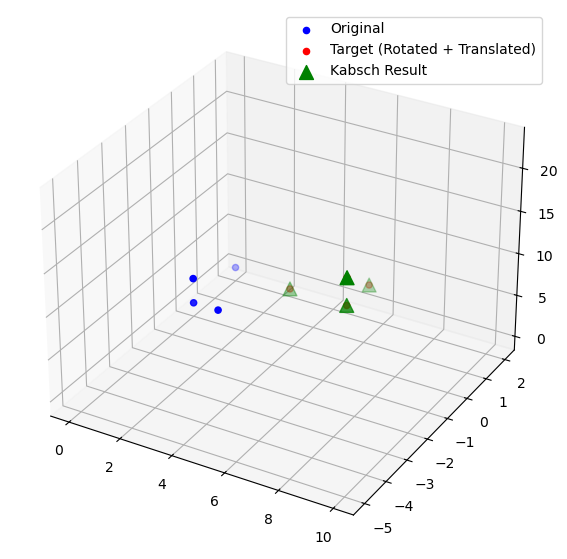

In [104]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot Source (Blue)
ax.scatter(source_pts[:,0], source_pts[:,1], source_pts[:,2], color='blue', label='Original')
# Plot Target (Red)
ax.scatter(target_pts[:,0], target_pts[:,1], target_pts[:,2], color='red', label='Target (Rotated + Translated)')
# Plot Recovered (Green Triangles)
ax.scatter(recovered_pts[:,0], recovered_pts[:,1], recovered_pts[:,2], color='green', marker='^', s=100, label='Kabsch Result')

ax.legend()
plt.show()

In [111]:
import pandas as pd
import numpy as np
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.atlas import StaticGaussianAtlas

# 1. Initialize the Atlas
# Using parameters consistent with your rotation project settings
atlas = StaticGaussianAtlas("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv", min_samples=10)

# --- Path A: Batch Data (from CSV) ---
# Assuming 'raw_df' is your loaded registered_all_points.csv
batch_df = pd.read_csv("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv")
try:
    # Testing timepoint 11 for embryo 191108 (N=4 valid cells)
    batch_frame = EmbryoFrame.from_dataframe(batch_df, embryo_id=191108, time_idx=13)
    batch_frame.prepare()
    print(f"✅ Batch Success: {batch_frame}")
    print(f"   PC1 Axis: {np.round(batch_frame.pc1_axis, 3)}")
except Exception as e:
    print(f"❌ Batch Failed: {e}")

# --- Path B: Inference Data (from Matrix) ---
raw_matrix = np.array([
    [238.28, 208.78, 30.075],
    [64.15, 103.46, 37.583],
    [367.88, 179.08, 35.397],
    [441.71, 170.37, 37.234],
    [278.83, 57.818, 45.671],
    [312.86, 255.17, 51.792],
    [433.0, 170.07, 47.472],
    [103.11, 195.8, 55.0]
])
try:
    inf_frame = EmbryoFrame.from_matrix(raw_matrix, embryo_id="Inference_Test")
    inf_frame.prepare()
    print(f"✅ Inference Success: {inf_frame}")
    print(f"   PC1 Axis: {np.round(inf_frame.pc1_axis, 3)}")
except Exception as e:
    print(f"❌ Inference Failed: {e}")

# --- Path C: Reference Frame (Atlas Logic) ---
# Testing the retrieval of parameters for a 4-cell stage
labels = ("ABa", "ABp", "EMS", "P2")
try:
    ref_frame = ReferenceFrame(labels, atlas)
    print(f"✅ Reference Success: {ref_frame}")
    print(f"   Means Shape: {ref_frame.means.shape}") # Should be (4, 3)
    print(f"   InvCovs Shape: {ref_frame.inv_covs.shape}") # Should be (4, 3, 3)
except Exception as e:
    print(f"❌ Reference Failed: {e}")

✅ Batch Success: EmbryoFrame(ID=191108, T=13, N=6)
   PC1 Axis: [-0.999  0.046 -0.007]
✅ Inference Success: EmbryoFrame(ID=Inference_Test, T=0, N=8)
   PC1 Axis: [ 0.994  0.106 -0.007]
❌ Reference Failed: "Critical Error: Cell 'ABa' missing from Atlas."


In [116]:
import pandas as pd
import numpy as np
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.atlas import StaticGaussianAtlas
from aligner.inventory import SliceAtlas

# 1. Initialize Atlases
# Lower min_samples if necessary to ensure labels like 'ABa' are loaded
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"

gauss_atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slice_db = SliceAtlas(SLICE_PATH)

# 2. Load Batch Data
BATCH_CSV = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv"
batch_df = pd.read_csv(BATCH_CSV)

# 3. Test Retrieval and Preparation for a specific Embryo/Timepoint
try:
    # We'll use Embryo 191108 at T=13 (which your data shows has 6 valid cells)
    target_embryo = 191108
    target_time = 13
    
    # Create and prepare the experimental frame
    frame = EmbryoFrame.from_dataframe(batch_df, target_embryo, target_time)
    frame.prepare()
    
    print(f"✅ EmbryoFrame Loaded: {frame}")
    print(f"   Valid Cells (N): {len(frame)}")
    print(f"   Scale Factor: {frame.scale_factor:.4f}")
    print(f"   PC1 Axis: {np.round(frame.pc1_axis, 3)}")

    # 4. Query the SliceAtlas for matching biological hypotheses
    candidates = slice_db.get_candidates(len(frame))
    print(f"\n✅ SliceAtlas Found {len(candidates)} candidates for N={len(frame)}")
    
    if candidates:
        # Test inflating the first candidate into a ReferenceFrame
        first_candidate = candidates[0]
        ref_frame = ReferenceFrame(first_candidate, gauss_atlas)
        
        print(f"\n✅ ReferenceFrame Success: {ref_frame}")
        print(f"   Atlas PC1 Axis: {np.round(ref_frame.pc1_axis, 3)}")
        print(f"   Means Shape: {ref_frame.means.shape}")
        print(f"   InvCovs Shape: {ref_frame.inv_covs.shape}")
    else:
        print(f"⚠️ Warning: No slices found in DB for N={len(frame)}")

except Exception as e:
    print(f"❌ Test Failed: {e}")

✅ EmbryoFrame Loaded: EmbryoFrame(ID=191108, T=13, N=6)
   Valid Cells (N): 6
   Scale Factor: 17.9659
   PC1 Axis: [-0.999  0.046 -0.007]

✅ SliceAtlas Found 1 candidates for N=6

✅ ReferenceFrame Success: ReferenceFrame(N=6, labels=('ABal', 'ABar', 'ABpl')...)
   Atlas PC1 Axis: [-0.984  0.163 -0.075]
   Means Shape: (6, 3)
   InvCovs Shape: (6, 3, 3)


In [120]:
import pandas as pd
import numpy as np
from aligner.models import EmbryoFrame

# 1. Load the raw inference data
# This CSV contains raw X, Y, Z pixel coordinates
INFERENCE_CSV = "/Users/miles/Documents/UCLA/shah_lab/cell_naming/Working Naming/test_data/Pos13.csv"
raw_pts_df = pd.read_csv(INFERENCE_CSV)

# 2. Define pixel scalings (microns per pixel)
# Using defaults or specific values from your imaging setup
PX_XY = 1.0 
PX_Z = 1.0

try:
    # 3. Initialize from matrix with pixel scaling
    # We use the factory method to handle the physical conversion
    inf_frame = EmbryoFrame.from_matrix(
        raw_pts_df[["X", "Y", "Z"]].values, 
        embryo_id="Pos13",
        px_xy=PX_XY,
        px_z=PX_Z,
        mirror_lr=False # Match the legacy mirror_lr option
    )
    
    # 4. Prepare the frame (Calculates scale factor and PC1)
    inf_frame.prepare()
    
    print(f"✅ Inference Frame Success: {inf_frame}")
    print(f"   N Points: {len(inf_frame)}")
    print(f"   Median Scale Factor: {inf_frame.scale_factor:.4f}")
    print(f"   Calculated PC1: {np.round(inf_frame.pc1_axis, 3)}")
    
    # 5. Sanity Check on Normalized Coordinates
    # These should be centered around zero
    mean_pos = np.round(inf_frame.normalized_coords.mean(axis=0), 5)
    print(f"   Normalized Mean (should be ~0): {mean_pos}")

except Exception as e:
    print(f"❌ Inference Path Failed: {e}")

✅ Inference Frame Success: EmbryoFrame(ID=Pos13, T=0, N=8)
   N Points: 8
   Median Scale Factor: 198.7277
   Calculated PC1: [ 0.994  0.106 -0.007]
   Normalized Mean (should be ~0): [-0. -0.  0.]


In [121]:
inf_frame

EmbryoFrame(ID=Pos13, T=0, N=8)

In [122]:
candidates = slice_db.get_candidates(len(inf_frame))
candidates

[('ABal', 'ABar', 'ABpl', 'ABpr', 'C', 'E', 'MS', 'P3')]

In [11]:
import pandas as pd
import numpy as np
#from aligner.models import EmbryoFrame, ReferenceFrame
#from aligner.atlas import StaticGaussianAtlas, SliceAtlas

# 1. Initialize the components
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"

# Load with min_samples=0 to ensure all labels are available for testing
gauss_atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slice_db = SliceAtlas(SLICE_PATH)

# 2. Simulate finding an embryo at the 8-cell stage
N_TEST = 8
candidate_ids = slice_db.get_candidates(N_TEST)

print(f"--- Slice Selection Test (N={N_TEST}) ---")
print(f"Found Slice IDs: {candidate_ids}") # Should include ID 7

if candidate_ids:
    # 3. Pick the first candidate ID and retrieve its labels
    target_id = candidate_ids[0]
    labels = slice_db.get_labels(target_id)
    print(f"✅ Slice ID {target_id} Labels: {labels}")

    # 4. Inflate labels into a ReferenceFrame (The biological hypothesis)
    try:
        ref_frame = ReferenceFrame(labels, gauss_atlas)
        
        print(f"\n✅ ReferenceFrame Success (Slice ID {target_id})")
        print(f"   Means Shape: {ref_frame.means.shape}") # Should be (8, 3)
        print(f"   Atlas PC1: {np.round(ref_frame.pc1_axis, 3)}")
        
        # Verify Mahalanobis component (Inverse Covariances)
        print(f"   InvCovs Shape: {ref_frame.inv_covs.shape}") # (8, 3, 3)
        
    except KeyError as e:
        print(f"❌ Reference Generation Failed: {e}")
else:
    print(f"❌ No slices found for N={N_TEST}")

--- Slice Selection Test (N=8) ---
Found Slice IDs: [7]
✅ Slice ID 7 Labels: ('ABal', 'ABar', 'ABpl', 'ABpr', 'C', 'E', 'MS', 'P3')

✅ ReferenceFrame Success (Slice ID 7)
   Means Shape: (8, 3)
   Atlas PC1: [-0.954  0.298  0.017]
   InvCovs Shape: (8, 3, 3)


Running alignment for EmbryoFrame(ID=191108, T=13, N=6)...
✅ Alignment Complete!
   Matched Slice ID: 5
   Final Mahalanobis Cost: 84.8538


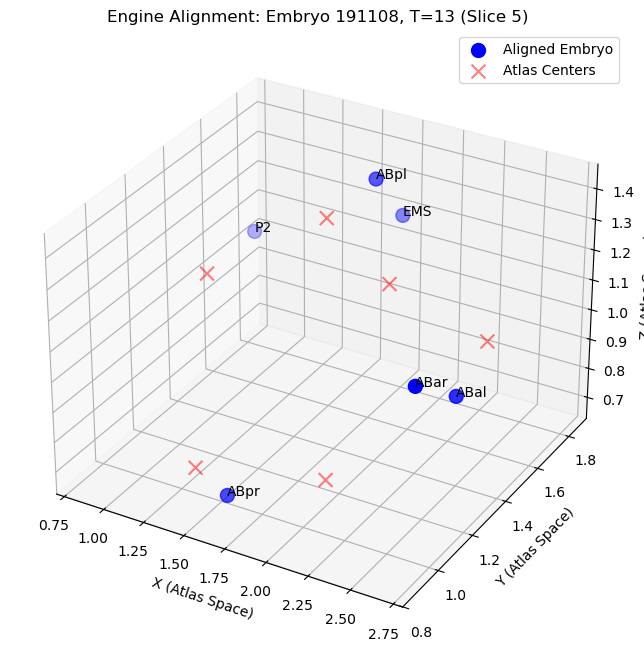

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.engine import LegacyEngine
#from aligner.atlas import StaticGaussianAtlas, SliceAtlas
from aligner.transformer import RigidTransformer

# 1. Setup Components
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"

BATCH_CSV = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv"

atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slices = SliceAtlas(SLICE_PATH)
engine = LegacyEngine(atlas, slices, HungarianMatcher(), RigidTransformer())

# 2. Load Real Data (Embryo 191108, T=13 is a 6-cell stage)
batch_df = pd.read_csv(BATCH_CSV)
frame = EmbryoFrame.from_dataframe(batch_df, 191108, 13)

# 3. Run the Engine
print(f"Running alignment for {frame}...")
result = engine.align_frame(frame)

print(f"✅ Alignment Complete!")
print(f"   Matched Slice ID: {result['slice_id']}")
print(f"   Final Mahalanobis Cost: {result['cost']:.4f}")

# 4. 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Aligned Embryo Points
coords = result['coords']
labels = result['labels']
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c='blue', s=100, label='Aligned Embryo')

# Annotate each point with its inferred label
for i, txt in enumerate(labels):
    ax.text(coords[i, 0], coords[i, 1], coords[i, 2], txt, fontsize=10)

# Plot Atlas Means for comparison
# We get the 'ground truth' means for this slice ID to see how close we got
ref_labels = slices.id_to_labels[result['slice_id']]
atlas_means, _, _ = atlas.get_params(list(ref_labels))
ax.scatter(atlas_means[:, 0], atlas_means[:, 1], atlas_means[:, 2], 
           c='red', marker='x', s=100, alpha=0.5, label='Atlas Centers')

ax.set_title(f"Engine Alignment: Embryo 191108, T=13 (Slice {result['slice_id']})")
ax.set_xlabel('X (Atlas Space)')
ax.set_ylabel('Y (Atlas Space)')
ax.set_zlabel('Z (Atlas Space)')
ax.legend()
plt.show()

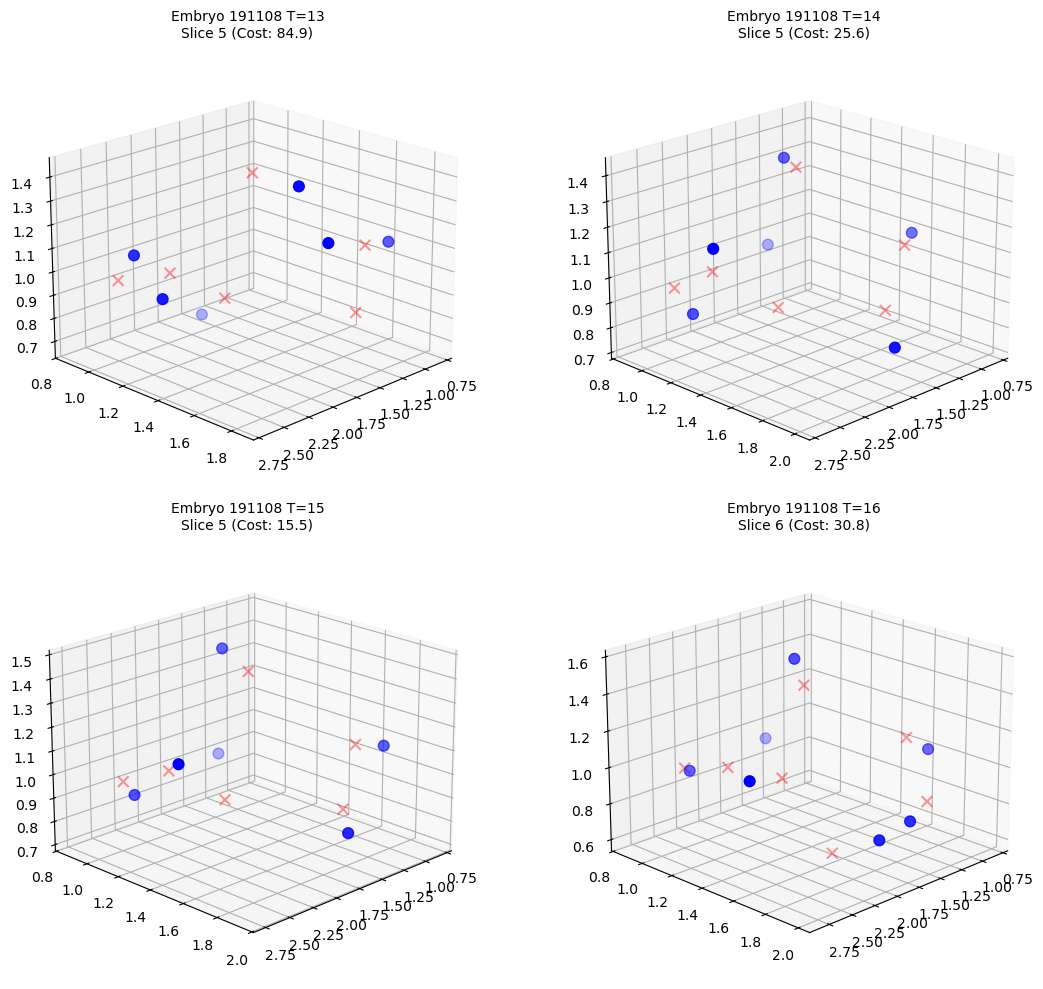

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_embryo_facets(embryo_targets: list, batch_df, engine, atlas, slices):
    """
    Creates a grid of 3D plots for multiple embryo alignment checks.
    
    Args:
        embryo_targets: List of tuples (embryo_id, time_idx)
    """
    n_plots = len(embryo_targets)
    cols = 2
    rows = (n_plots + 1) // cols
    
    fig = plt.figure(figsize=(12, 5 * rows))
    
    for i, (eid, tid) in enumerate(embryo_targets):
        # 1. Load and align
        frame = EmbryoFrame.from_dataframe(batch_df, eid, tid)
        result = engine.align_frame(frame)
        
        # 2. Add 3D subplot to the grid
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
        
        # 3. Plot Aligned Embryo
        coords = result['coords']
        labels = result['labels']
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c='blue', s=60, label='Aligned')
        
        # 4. Plot Atlas Centers for the matched slice
        ref_labels = slices.id_to_labels[result['slice_id']]
        atlas_means, _, _ = atlas.get_params(list(ref_labels))
        ax.scatter(atlas_means[:, 0], atlas_means[:, 1], atlas_means[:, 2], 
                   c='red', marker='x', s=60, alpha=0.4, label='Atlas')
        
        ax.set_title(f"Embryo {eid} T={tid}\nSlice {result['slice_id']} (Cost: {result['cost']:.1f})", fontsize=10)
        ax.view_init(elev=20, azim=45) # Consistent viewing angle for comparison
        
    plt.tight_layout()
    plt.show()

# Example: Testing multiple timepoints for Embryo 191108
targets = [(191108, 13), (191108, 14), (191108, 15), (191108, 16)]
plot_embryo_facets(targets, batch_df, engine, atlas, slices)

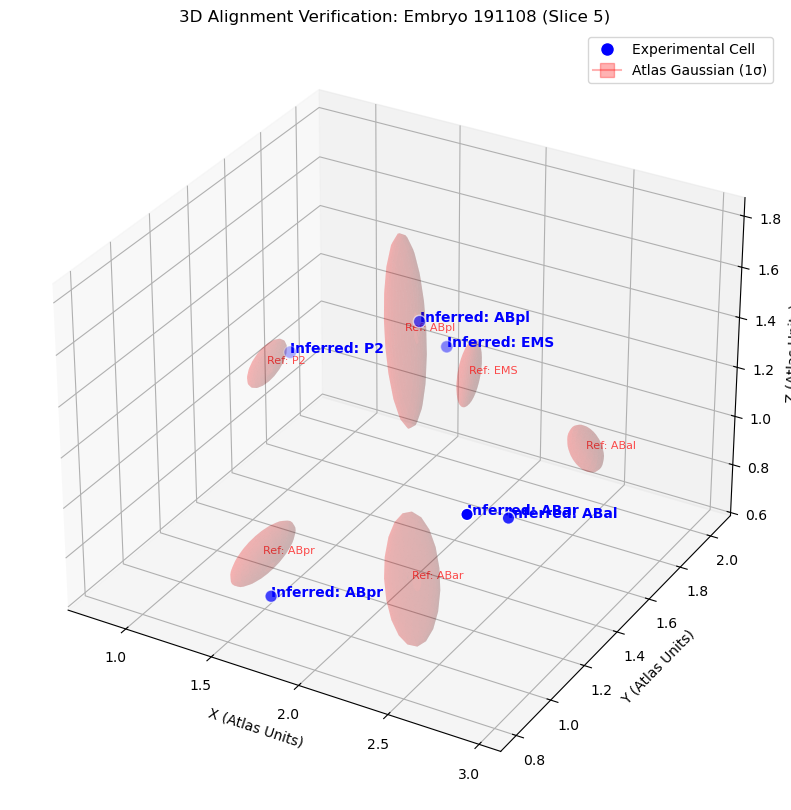

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def draw_ellipsoid(ax, center, cov, label, color='r', alpha=0.1):
    """Calculates and plots a 1-sigma ellipsoid surface."""
    # 1. Get eigenvalues and eigenvectors
    U, s, Rotation = np.linalg.svd(cov)
    radii = np.sqrt(s) # 1-standard deviation lengths

    # 2. Generate sphere surface points
    u = np.linspace(0.0, 2.0 * np.pi, 20)
    v = np.linspace(0.0, np.pi, 20)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    # 3. Transform sphere to ellipsoid
    # Scale, Rotate, and Translate
    ellipsoid = np.stack([x, y, z], axis=-1) @ np.diag(radii) @ Rotation.T + center
    
    # 4. Plot surface
    ax.plot_surface(ellipsoid[:,:,0], ellipsoid[:,:,1], ellipsoid[:,:,2], 
                    color=color, alpha=alpha, linewidth=0)

# --- Plotting Block ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Get the reference frame used by the engine for this winner
target_labels = slices.id_to_labels[result['slice_id']]
ref_frame = ReferenceFrame(target_labels, atlas)

# 2. Plot Atlas Gaussians (Ellipsoids + Means)
for i, label in enumerate(ref_frame.labels):
    # Use centered means and the stored covariance matrices
    mu = ref_frame.means[i]
    cov = ref_frame.covs[i]
    
    # Draw 1-sigma ellipsoid
    draw_ellipsoid(ax, mu, cov, label, color='red', alpha=0.15)
    
    # Label the atlas cell type
    ax.text(mu[0], mu[1], mu[2], f"Ref: {label}", color='red', fontsize=8, alpha=0.7)

# 3. Plot Aligned Embryo Data
coords = result['coords']
inf_labels = result['labels']
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c='blue', s=80, label='Aligned Embryo', edgecolors='white')

# Label the inferred cell types
for i, txt in enumerate(inf_labels):
    ax.text(coords[i, 0], coords[i, 1], coords[i, 2], f"Inferred: {txt}", color='blue', fontweight='bold')

ax.set_title(f"3D Alignment Verification: Embryo 191108 (Slice {result['slice_id']})")
ax.set_xlabel('X (Atlas Units)')
ax.set_ylabel('Y (Atlas Units)')
ax.set_zlabel('Z (Atlas Units)')
# Custom legend for clarity
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Experimental Cell', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='s', color='red', label='Atlas Gaussian (1σ)', markersize=10, alpha=0.3)]
ax.legend(handles=legend_elements)

plt.show()

In [15]:
import numpy as np
import pandas as pd
from aligner.atlas import StaticGaussianAtlas
from aligner.inventory import SliceAtlas
from aligner.matcher import HungarianMatcher
from aligner.transformer import RigidTransformer
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.engine import LegacyEngine

def run_debug_test():
    # 1. Setup Mock Data
    # Simulate an atlas with 4 cells in a simple tetrahedral-ish shape
    mock_atlas_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [10.0, 20.0, 15.0, 15.0],
        'mu_y': [10.0, 10.0, 20.0, 15.0],
        'mu_z': [0.0, 0.0, 0.0, 10.0],
        'n_samples': [10, 10, 10, 10],
        'cov_xx': [1, 1, 1, 1], 'cov_yy': [1, 1, 1, 1], 'cov_zz': [1, 1, 1, 1],
        'cov_xy': [0, 0, 0, 0], 'cov_xz': [0, 0, 0, 0], 'cov_yz': [0, 0, 0, 0]
    }
    pd.DataFrame(mock_atlas_data).to_csv('mock_atlas.csv', index=False)
    
    mock_slice_data = {
        'slice_id': [1],
        'n_cells_frame': [4],
        'cell_names': ['A;B;C;D']
    }
    pd.DataFrame(mock_slice_data).to_csv('mock_slices.csv', index=False)

    # 2. Initialize Components
    atlas = StaticGaussianAtlas('mock_atlas.csv')
    slice_db = SliceAtlas('mock_slices.csv')
    matcher = HungarianMatcher()
    transformer = RigidTransformer()
    engine = LegacyEngine(atlas, slice_db, matcher, transformer)

    # 3. Create Synthetic "Experimental" Frame
    # Take ground truth means
    gt_means = np.array([
        [10.0, 10.0, 0.0], [20.0, 10.0, 0.0], [15.0, 20.0, 0.0], [15.0, 15.0, 10.0]
    ])
    
    # Apply a known 90-degree rotation around Z and a translation
    theta = np.radians(90)
    gt_R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ]).T # Row-based as per your transformer logic
    
    gt_t = np.array([5.0, -2.0, 10.0])
    exp_coords = gt_means @ gt_R + gt_t
    
    frame = EmbryoFrame(exp_coords, "Debug_Embryo", 0)
    
    # 4. Run Alignment
    print("Starting alignment...")
    result = engine.align_frame(frame)
    
    # 5. Validation
    print("\n--- Validation Results ---")
    print(f"Matched Slice ID: {result['slice_id']} (Expected: 1)")
    print(f"Assigned Labels: {result['labels']}")
    
    # Check if the coordinates in 'result' are close to the original atlas means
    dist_to_atlas = np.linalg.norm(result['coords'] - gt_means, axis=1).mean()
    print(f"Mean distance to Atlas: {dist_to_atlas:.6f}")
    
    if dist_to_atlas < 1e-3:
        print("SUCCESS: The embryo was correctly mapped back to atlas space.")
    else:
        print("FAILURE: Alignment failed to recover atlas coordinates.")

if __name__ == "__main__":
    run_debug_test()

Starting alignment...

--- Validation Results ---
Matched Slice ID: 1 (Expected: 1)
Assigned Labels: ['B', 'C', 'A', 'D']
Mean distance to Atlas: 6.926828
FAILURE: Alignment failed to recover atlas coordinates.


In [34]:
import numpy as np
import pandas as pd
from aligner.atlas import StaticGaussianAtlas
from aligner.matcher import HungarianMatcher
from aligner.transformer import RigidTransformer
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.engine import LegacyEngine

def informative_debug_scan():
    # 1. Setup Mock Atlas (Asymmetrical L-shape for unique rotation)
    mock_atlas_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 10.0, 0.0, 0.0],
        'mu_y': [0.0, 0.0, 20.0, 0.0],
        'mu_z': [0.0, 0.0, 0.0, 30.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_atlas_data).to_csv('coarse_atlas.csv', index=False)
    
    atlas = StaticGaussianAtlas('coarse_atlas.csv')
    ref_labels = ('A', 'B', 'C', 'D')
    ref_frame = ReferenceFrame(ref_labels, atlas)

    # 2. Setup Experimental Frame: Flip X (Antiparallel) + 45 deg roll
    centered_gt = ref_frame.centered_means
    
    # Legacy logic handles antiparallel vectors by rotating 180 deg around an ortho axis
    R_flip = np.array([[-1, 0, 0], [0, 1, 0], [0, 0, 1]]) 
    
    # 45 degree roll about the Atlas PC1 axis
    theta = np.radians(45)
    c, s = np.cos(theta), np.sin(theta)
    # Note: PC1 for this mock is roughly Z-axis [0, 0, 1]
    R_roll_gt = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    
    exp_coords = (centered_gt @ R_flip.T) @ R_roll_gt.T
    frame = EmbryoFrame(exp_coords, "Coarse_Test", 0)
    frame.prepare()

    print(f"CHECKPOINT 1: Axis Alignment")
    print(f"  Embryo PC1: {frame.pc1_axis}")
    print(f"  Atlas PC1:  {ref_frame.pc1_axis}")
    
    transformer = RigidTransformer()
    # Test if your transformer handles the antiparallel case (sign=-1.0)
    R_test = transformer.get_rotation_between_vectors(-1.0 * frame.pc1_axis, ref_frame.pc1_axis)
    det = np.linalg.det(R_test)
    print(f"  Transformer Det(R) for flipped axis: {det:.4f} (Should be 1.0, not -1.0)")
    if det < 0:
        print("  CRITICAL FAILURE: Transformer is returning a reflection, not a rotation.")

    # 3. Execution
    matcher = HungarianMatcher()
    engine = LegacyEngine(atlas, None, matcher, transformer)
    best_R, best_cost = engine._run_coarse_scan(frame, ref_frame)

    # 4. Final Diagnostics
    final_coords = frame.normalized_coords @ best_R + ref_frame.center_of_mass
    _, col_ind = matcher.match(final_coords, ref_frame.means)
    reconstruction_error = np.linalg.norm(final_coords - ref_frame.means[col_ind], axis=1).mean()

    print("\nCHECKPOINT 2: Optimization result")
    print(f"  Best Cost found: {best_cost:.4f}")
    print(f"  Final Mean Reconstruction Error: {reconstruction_error:.4f}")

    if reconstruction_error > 1.0:
        print("\nFAILURE ANALYSIS:")
        # Test if the correct rotation WAS found but overwritten due to indentation
        print("  Testing if optimal rotation was lost...")
        # (This is a simplified manual check for the GT rotation)
        manual_transformed = frame.normalized_coords @ (R_flip @ R_roll_gt) + ref_frame.center_of_mass
        manual_error = np.linalg.norm(manual_transformed - ref_frame.means, axis=1).mean()
        print(f"  Error using GT rotation: {manual_error:.4f}")
        if manual_error < 1.0:
            print("  ADVICE: The math works, but the engine is not saving the best result (Check loop indentation).")
    else:
        print("\nSUCCESS: Alignment recovered.")

if __name__ == "__main__":
    informative_debug_scan()

CHECKPOINT 1: Axis Alignment
  Embryo PC1: [-0.28403299  0.16584181 -0.94436315]
  Atlas PC1:  [-0.08357378 -0.31810952  0.94436315]
  Transformer Det(R) for flipped axis: 1.0000 (Should be 1.0, not -1.0)

CHECKPOINT 2: Optimization result
  Best Cost found: 971.8752
  Final Mean Reconstruction Error: 14.7217

FAILURE ANALYSIS:
  Testing if optimal rotation was lost...
  Error using GT rotation: 14.9679


In [35]:


def debug_alignment_pipeline():
    # 1. Setup Mock Atlas (Asymmetrical to catch rotation errors)
    mock_atlas_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [10.0, 20.0, 10.0, 10.0],
        'mu_y': [10.0, 10.0, 20.0, 10.0],
        'mu_z': [0.0, 0.0, 0.0, 10.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_atlas_data).to_csv('diagnostic_atlas.csv', index=False)
    
    atlas = StaticGaussianAtlas('diagnostic_atlas.csv')
    ref_labels = ('A', 'B', 'C', 'D')
    ref_frame = ReferenceFrame(ref_labels, atlas)

    # 2. Manual Transformation (Ground Truth)
    # We create an embryo exactly like the atlas, but rotated 90 deg around Z
    theta = np.radians(90)
    c, s = np.cos(theta), np.sin(theta)
    gt_R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]]).T # Row-based
    
    # Start with absolute means, center them, rotate, and keep at origin
    gt_centered = ref_frame.means - ref_frame.center_of_mass
    exp_coords = gt_centered @ gt_R
    
    frame = EmbryoFrame(exp_coords, "Diag_Embryo", 0)
    frame.prepare()

    print("--- STEP 1: PC1 Consistency ---")
    print(f"Atlas PC1:  {ref_frame.pc1_axis}")
    print(f"Embryo PC1: {frame.pc1_axis}")
    # The dot product of aligned PC1s should be ~1.0
    print(f"PC1 Alignment Dot Product: {np.abs(np.dot(frame.pc1_axis, ref_frame.pc1_axis)):.4f}")

    print("\n--- STEP 2: Transformer Logic ---")
    transformer = RigidTransformer()
    # Try to recover the 90 degree rotation
    R_recovered = transformer.get_rotation_between_vectors(frame.pc1_axis, ref_frame.pc1_axis)
    print(f"Recovered R Determinant: {np.linalg.det(R_recovered):.4f} (Must be 1.0)")
    
    print("\n--- STEP 3: Space Mapping (The likely culprit) ---")
    # This simulates exactly what happens inside _run_coarse_scan
    # We test if 'transformed' actually lands on 'ref_frame.means'
    test_transformed = frame.normalized_coords @ R_recovered + ref_frame.center_of_mass
    
    matcher = HungarianMatcher()
    _, col_ind = matcher.match(test_transformed, ref_frame.means)
    
    mean_dist = np.linalg.norm(test_transformed - ref_frame.means[col_ind], axis=1).mean()
    print(f"Mean Distance to Atlas after PC1 Alignment: {mean_dist:.4f}")
    
    if mean_dist > 5.0:
        print("\n[CRITICAL ERROR FOUND]")
        print("The rotated points are not in the same neighborhood as the Atlas.")
        print(f"Atlas Center: {ref_frame.center_of_mass}")
        print(f"Rotated Embryo Center: {test_transformed.mean(axis=0)}")
        print("Check if EmbryoFrame.prepare() is centering correctly.")

    print("\n--- STEP 4: Full Engine Coarse Scan ---")
    engine = LegacyEngine(atlas, None, matcher, transformer)
    best_R, best_cost = engine._run_coarse_scan(frame, ref_frame)
    
    final_coords = frame.normalized_coords @ best_R + ref_frame.center_of_mass
    final_error = np.linalg.norm(final_coords - ref_frame.means, axis=1).mean()
    print(f"Engine Coarse Scan Error: {final_error:.4f}")

if __name__ == "__main__":
    debug_alignment_pipeline()

--- STEP 1: PC1 Consistency ---
Atlas PC1:  [ 0.         -0.70710678  0.70710678]
Embryo PC1: [-0.81649658 -0.40824829 -0.40824829]
PC1 Alignment Dot Product: 0.0000

--- STEP 2: Transformer Logic ---
Recovered R Determinant: 1.0000 (Must be 1.0)

--- STEP 3: Space Mapping (The likely culprit) ---
Mean Distance to Atlas after PC1 Alignment: 6.8613

[CRITICAL ERROR FOUND]
The rotated points are not in the same neighborhood as the Atlas.
Atlas Center: [12.5 12.5  2.5]
Rotated Embryo Center: [12.5 12.5  2.5]
Check if EmbryoFrame.prepare() is centering correctly.

--- STEP 4: Full Engine Coarse Scan ---
Engine Coarse Scan Error: 7.6354


In [6]:
import numpy as np
import pandas as pd
from aligner.atlas import StaticGaussianAtlas
from aligner.matcher import HungarianMatcher
from aligner.transformer import RigidTransformer
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.engine import LegacyEngine

def test_coarse_rotation_logic():
    # 1. Setup Mock Atlas (Asymmetrical to ensure only one correct rotation)
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [10.0, 30.0, 10.0, 10.0],
        'mu_y': [10.0, 10.0, 20.0, 10.0],
        'mu_z': [0.0, 0.0, 0.0, 15.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('test_atlas.csv', index=False)
    
    atlas = StaticGaussianAtlas('test_atlas.csv')
    ref_labels = ('A', 'B', 'C', 'D')
    ref_frame = ReferenceFrame(ref_labels, atlas)

    # 2. Create Synthetic Embryo (Same Scale)
    # Start with Atlas means centered at origin
    gt_centered = ref_frame.means - ref_frame.center_of_mass
    
    # Apply 90 degree rotation around Atlas PC1 axis
    theta = np.radians(90)
    transformer = RigidTransformer()
    R_gt = transformer.get_rotation_about_axis(ref_frame.pc1_axis, theta)
    
    # Also add a PC1 flip to test the 'sign' logic
    R_flip = transformer.get_rotation_between_vectors(ref_frame.pc1_axis, -ref_frame.pc1_axis)
    
    # Experimental coords = Origin-centered, flipped, and rolled
    exp_coords = (gt_centered @ R_flip) @ R_gt
    
    # Create Frame and bypass scaling issues by forcing scale_factor to 1.0
    frame = EmbryoFrame(exp_coords, "Test_Embryo", 0)
    frame.prepare()
    frame.scale_factor = 1.0 
    frame.normalized_coords = exp_coords # Force identical scale

    # 3. Execution
    matcher = HungarianMatcher()
    engine = LegacyEngine(atlas, None, matcher, transformer)
    
    print(f"--- Alignment Search ---")
    best_R, best_cost = engine._run_coarse_scan(frame, ref_frame)

    # 4. Final Verification
    # Apply found rotation and move to Atlas space
    final_coords = frame.normalized_coords @ best_R + ref_frame.center_of_mass
    
    # Check if the points landed on the Atlas means
    _, col_ind = matcher.match(final_coords, ref_frame.means)
    error = np.linalg.norm(final_coords - ref_frame.means[col_ind], axis=1).mean()

    print(f"Resulting Cost: {best_cost:.4f}")
    print(f"Mean Reconstruction Error: {error:.4f}")
    
    if error < 0.1:
        print("\nSUCCESS: Coarse rotation recovered perfectly at identical scale.")
    else:
        print("\nFAILURE: Even with identical scales, the rotation logic is incorrect.")
        print("Check if R_total = R_initial @ R_roll or R_roll @ R_initial.")

if __name__ == "__main__":
    test_coarse_rotation_logic()

--- Alignment Search ---
Resulting Cost: 0.0007
Mean Reconstruction Error: 0.0122

SUCCESS: Coarse rotation recovered perfectly at identical scale.


In [7]:


def comprehensive_rotation_audit():
    # 1. Setup a "Gold Standard" Atlas
    # Highly asymmetrical L-shape to make any rotation error obvious
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 20.0, 0.0, 0.0],
        'mu_y': [0.0, 0.0, 10.0, 0.0],
        'mu_z': [0.0, 0.0, 0.0, 5.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('audit_atlas.csv', index=False)
    atlas = StaticGaussianAtlas('audit_atlas.csv')
    ref_frame = ReferenceFrame(('A', 'B', 'C', 'D'), atlas)

    # 2. Setup Experimental Frame: Known 90-deg roll and 180-deg flip
    transformer = RigidTransformer()
    gt_roll_angle = np.radians(90)
    
    # Generate Ground Truth Rotation (Match your row-based convention)
    R_flip = transformer.get_rotation_between_vectors(ref_frame.pc1_axis, -ref_frame.pc1_axis)
    R_roll = transformer.get_rotation_about_axis(ref_frame.pc1_axis, gt_roll_angle)
    gt_R = R_flip @ R_roll # This matches LegacyEngine order: align axes, then roll
    
    # Build Frame at origin (Simulate normalized_coords)
    exp_coords = ref_frame.centered_means @ gt_R
    frame = EmbryoFrame(exp_coords, "Audit_Embryo", 0)
    frame.prepare()
    # Lock scale factor to 1.0 to isolate rotation/translation
    frame.scale_factor = 1.0
    frame.normalized_coords = exp_coords

    print("--- DIAGNOSTIC DATA ---")
    print(f"Atlas COM:    {ref_frame.center_of_mass}")
    print(f"Embryo PC1:   {frame.pc1_axis}")
    print(f"Atlas PC1:    {ref_frame.pc1_axis}")
    print(f"Initial Dot:  {np.dot(frame.pc1_axis, ref_frame.pc1_axis):.4f}")

    # 3. Exhaustive Cost Sweep
    # We manually replicate the engine loop to see the cost curve
    results = []
    engine = LegacyEngine(atlas, None, HungarianMatcher(), transformer)
    
    for sign in [+1.0, -1.0]:
        R_init = transformer.get_rotation_between_vectors(sign * frame.pc1_axis, ref_frame.pc1_axis)
        n_steps = int(2 * np.pi / engine.angle_step_rad)
        
        for i in range(n_steps):
            angle = i * engine.angle_step_rad
            R_roll_step = transformer.get_rotation_about_axis(ref_frame.pc1_axis, angle)
            R_total = R_init @ R_roll_step
            
            # Apply transformation
            transformed = frame.normalized_coords @ R_total + ref_frame.center_of_mass
            _, col_ind = engine.matcher.match(transformed, ref_frame.means)
            cost = np.sum((transformed - ref_frame.means[col_ind])**2)
            
            results.append({
                'sign': sign,
                'angle_deg': np.degrees(angle),
                'cost': cost,
                'det': np.linalg.det(R_total),
                'com_error': np.linalg.norm(transformed.mean(axis=0) - ref_frame.center_of_mass)
            })

    # 4. Analysis
    df = pd.DataFrame(results)
    best_step = df.loc[df['cost'].idxmin()]
    
    print("\n--- RESULTS ANALYSIS ---")
    print(f"Global Min Cost:    {best_step['cost']:.6f} at {best_step['angle_deg']:.1f} deg (Sign: {best_step['sign']})")
    print(f"Determinant Check:  {best_step['det']:.4f} (Must be 1.0)")
    print(f"Translation Error:  {best_step['com_error']:.6e} (Must be near 0)")

    # 5. Pipeline Logic Check
    # We call the actual engine method to see if it retrieves the same minimum
    engine_R, engine_cost = engine._run_coarse_scan(frame, ref_frame)
    print(f"\nEngine Reported Cost: {engine_cost:.6f}")
    
    if not np.isclose(engine_cost, best_step['cost']):
        print("CRITICAL: Engine method failed to return the global minimum found in the sweep!")
        print("Check for local variable shadowing or incorrect cost comparison logic.")

if __name__ == "__main__":
    comprehensive_rotation_audit()

--- DIAGNOSTIC DATA ---
Atlas COM:    [0.32071491 0.16035746 0.08017873]
Embryo PC1:   [-0.97656547  0.20188326  0.07458573]
Atlas PC1:    [ 0.97656547 -0.20188326 -0.07458573]
Initial Dot:  -1.0000

--- RESULTS ANALYSIS ---
Global Min Cost:    0.000409 at 92.0 deg (Sign: 1.0)
Determinant Check:  1.0000 (Must be 1.0)
Translation Error:  3.103168e-17 (Must be near 0)

Engine Reported Cost: 0.000409


In [3]:


def comprehensive_rotation_audit():
    # 1. Setup a "Gold Standard" Atlas
    # Highly asymmetrical L-shape to make any rotation error obvious
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 20.0, 0.0, 0.0],
        'mu_y': [0.0, 0.0, 10.0, 0.0],
        'mu_z': [0.0, 0.0, 0.0, 5.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('audit_atlas.csv', index=False)
    atlas = StaticGaussianAtlas('audit_atlas.csv')
    ref_frame = ReferenceFrame(('A', 'B', 'C', 'D'), atlas)

    # 2. Setup Experimental Frame: Known 90-deg roll and 180-deg flip
    transformer = RigidTransformer()
    gt_roll_angle = np.radians(90)
    
    # Generate Ground Truth Rotation (Match your row-based convention)
    R_flip = transformer.get_rotation_between_vectors(ref_frame.pc1_axis, -ref_frame.pc1_axis)
    R_roll = transformer.get_rotation_about_axis(ref_frame.pc1_axis, gt_roll_angle)
    gt_R = R_flip @ R_roll # This matches LegacyEngine order: align axes, then roll
    
    # Build Frame at origin (Simulate normalized_coords)
    exp_coords = ref_frame.centered_means @ gt_R
    frame = EmbryoFrame(exp_coords, "Audit_Embryo", 0)
    frame.prepare()
    # Lock scale factor to 1.0 to isolate rotation/translation
    frame.scale_factor = 1.0
    frame.normalized_coords = exp_coords

    print("--- DIAGNOSTIC DATA ---")
    print(f"Atlas COM:    {ref_frame.center_of_mass}")
    print(f"Embryo PC1:   {frame.pc1_axis}")
    print(f"Atlas PC1:    {ref_frame.pc1_axis}")
    print(f"Initial Dot:  {np.dot(frame.pc1_axis, ref_frame.pc1_axis):.4f}")

    # 3. Exhaustive Cost Sweep
    # We manually replicate the engine loop to see the cost curve
    results = []
    engine = LegacyEngine(atlas, None, HungarianMatcher(), transformer)
    
    for sign in [+1.0, -1.0]:
        R_init = transformer.get_rotation_between_vectors(sign * frame.pc1_axis, ref_frame.pc1_axis)
        n_steps = int(2 * np.pi / engine.angle_step_rad)
        
        for i in range(n_steps):
            angle = i * engine.angle_step_rad
            R_roll_step = transformer.get_rotation_about_axis(ref_frame.pc1_axis, angle)
            R_total = R_init @ R_roll_step
            
            # Apply transformation
            transformed = frame.normalized_coords @ R_total + ref_frame.center_of_mass
            _, col_ind = engine.matcher.match(transformed, ref_frame.means)
            cost = np.sum((transformed - ref_frame.means[col_ind])**2)
            
            results.append({
                'sign': sign,
                'angle_deg': np.degrees(angle),
                'cost': cost,
                'det': np.linalg.det(R_total),
                'com_error': np.linalg.norm(transformed.mean(axis=0) - ref_frame.center_of_mass)
            })

    # 4. Analysis
    df = pd.DataFrame(results)
    best_step = df.loc[df['cost'].idxmin()]
    
    print("\n--- RESULTS ANALYSIS ---")
    print(f"Global Min Cost:    {best_step['cost']:.6f} at {best_step['angle_deg']:.1f} deg (Sign: {best_step['sign']})")
    print(f"Determinant Check:  {best_step['det']:.4f} (Must be 1.0)")
    print(f"Translation Error:  {best_step['com_error']:.6e} (Must be near 0)")

    # 5. Pipeline Logic Check
    # We call the actual engine method to see if it retrieves the same minimum
    engine_R, engine_cost = engine._run_coarse_scan(frame, ref_frame)
    print(f"\nEngine Reported Cost: {engine_cost:.6f}")
    
    if not np.isclose(engine_cost, best_step['cost']):
        print("CRITICAL: Engine method failed to return the global minimum found in the sweep!")
        print("Check for local variable shadowing or incorrect cost comparison logic.")

if __name__ == "__main__":
    comprehensive_rotation_audit()

--- DIAGNOSTIC DATA ---
Atlas COM:    [0.32071491 0.16035746 0.08017873]
Embryo PC1:   [-0.97656547  0.20188326  0.07458573]
Atlas PC1:    [ 0.97656547 -0.20188326 -0.07458573]
Initial Dot:  -1.0000

--- RESULTS ANALYSIS ---
Global Min Cost:    0.000409 at 92.0 deg (Sign: 1.0)
Determinant Check:  1.0000 (Must be 1.0)
Translation Error:  3.103168e-17 (Must be near 0)

Engine Reported Cost: 0.000409


In [8]:


def debug_pipeline_geometry():
    # 1. Setup a strictly defined mock atlas (Asymmetrical L-shape)
    # PC1 should be clearly X, PC2 should be Y
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 50.0, 0.0, 0.0], # Long axis
        'mu_y': [0.0, 0.0, 20.0, 0.0], # Short axis
        'mu_z': [0.0, 0.0, 0.0, 5.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('pipeline_atlas.csv', index=False)
    
    # 2. Initialize ReferenceFrame
    atlas = StaticGaussianAtlas('pipeline_atlas.csv')
    ref_labels = ('A', 'B', 'C', 'D')
    ref_frame = ReferenceFrame(ref_labels, atlas)

    # 3. Initialize EmbryoFrame from the EXACT same raw coordinates
    # This tests if EmbryoFrame.prepare() and ReferenceFrame.__init__ are identical
    raw_coords = ref_frame.means * ref_frame.scale_factor # Recover original unscaled means
    frame = EmbryoFrame(raw_coords, "Synthetic_Embryo", 0)
    frame.prepare()

    print("--- CHECKPOINT 1: Scaling & Centering Parity ---")
    print(f"  Atlas Scale Factor:  {ref_frame.scale_factor:.6f}")
    print(f"  Embryo Scale Factor: {frame.scale_factor:.6f}")
    
    scale_diff = abs(ref_frame.scale_factor - frame.scale_factor)
    print(f"  Scale Difference:    {scale_diff:.6e} (Should be < 1e-10)")
    
    # Check if COM matches (should be at origin for centered_means)
    com_diff = np.linalg.norm(ref_frame.centered_means.mean(axis=0) - frame.normalized_coords.mean(axis=0))
    print(f"  COM Offset:          {com_diff:.6e} (Should be < 1e-10)")

    print("\n--- CHECKPOINT 2: PC1 Calculation Consistency ---")
    print(f"  Atlas PC1:  {ref_frame.pc1_axis}")
    print(f"  Embryo PC1: {frame.pc1_axis}")
    
    dot_prod = np.dot(ref_frame.pc1_axis, frame.pc1_axis)
    print(f"  PC1 Dot Product: {dot_prod:.6f} (Should be 1.0 or -1.0)")

    print("\n--- CHECKPOINT 3: Zero-Rotation Cost ---")
    # If identical, cost should be exactly 0 with identity rotation
    matcher = HungarianMatcher()
    transformed = frame.normalized_coords + ref_frame.center_of_mass
    _, col_ind = matcher.match(transformed, ref_frame.means)
    
    zero_rot_cost = np.sum((transformed - ref_frame.means[col_ind])**2)
    print(f"  Identity Rotation Cost: {zero_rot_cost:.6e}")
    if zero_rot_cost > 1e-10:
        print("  CRITICAL ERROR: Even with identity rotation, coordinates do not match!")
        print(f"  Sample Transformed[0]: {transformed[0]}")
        print(f"  Sample Ref Means[0]:    {ref_frame.means[0]}")

    print("\n--- CHECKPOINT 4: PC1 Search Logic ---")
    # Test if sign flip and rotation are recoverable
    engine = LegacyEngine(atlas, None, matcher, RigidTransformer())
    best_R, best_cost = engine._run_coarse_scan(frame, ref_frame)
    print(f"  Engine Coarse Scan Best Cost: {best_cost:.6e}")

if __name__ == "__main__":
    debug_pipeline_geometry()

--- CHECKPOINT 1: Scaling & Centering Parity ---
  Atlas Scale Factor:  35.307764
  Embryo Scale Factor: 35.307764
  Scale Difference:    0.000000e+00 (Should be < 1e-10)
  COM Offset:          0.000000e+00 (Should be < 1e-10)

--- CHECKPOINT 2: PC1 Calculation Consistency ---
  Atlas PC1:  [ 0.98784725 -0.15239752 -0.03054198]
  Embryo PC1: [ 0.98784725 -0.15239752 -0.03054198]
  PC1 Dot Product: 1.000000 (Should be 1.0 or -1.0)

--- CHECKPOINT 3: Zero-Rotation Cost ---
  Identity Rotation Cost: 0.000000e+00

--- CHECKPOINT 4: PC1 Search Logic ---
  Engine Coarse Scan Best Cost: 0.000000e+00


In [16]:


def test_coarse_roll_recovery():
    # 1. Setup Mock Atlas (Asymmetrical to force unique alignment)
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 40.0, 0.0, 0.0],  # Primary Axis
        'mu_y': [0.0, 0.0, 15.0, 0.0],  # Secondary Axis
        'mu_z': [0.0, 0.0, 0.0, 5.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('roll_test_atlas.csv', index=False)
    
    atlas = StaticGaussianAtlas('roll_test_atlas.csv')
    ref_frame = ReferenceFrame(('A', 'B', 'C', 'D'), atlas)

    # 2. Create a "Hidden" Rotation
    # Start with perfectly centered/normalized points from the atlas
    gt_centered = ref_frame.centered_means
    
    # Define a 45-degree roll and a 180-degree PC1 flip
    transformer = RigidTransformer()
    theta_gt = np.radians(45)
    
    # R_initial: Flip PC1 (Aligning positive X to negative X)
    R_flip = transformer.get_rotation_between_vectors(ref_frame.pc1_axis, -ref_frame.pc1_axis)
    # R_roll: Roll around the PC1 axis
    R_roll_gt = transformer.get_rotation_about_axis(ref_frame.pc1_axis, theta_gt)
    
    # Combine: First align, then roll
    # (Matches LegacyEngine order: R_total = R_align @ R_roll)
    gt_R = R_flip @ R_roll_gt
    
    # 3. Initialize EmbryoFrame
    # We simulate an embryo that is already centered/normalized but rotated
    exp_coords = gt_centered @ gt_R
    frame = EmbryoFrame(exp_coords, "Roll_Test_Embryo", 0)
    frame.prepare()
    
    # Bypass median scaling here to ensure perfectly identical scales for the math check
    frame.scale_factor = 1.0 
    frame.normalized_coords = exp_coords

    print("--- SEARCH DIAGNOSTICS ---")
    print(f"  Target PC1: {ref_frame.pc1_axis}")
    print(f"  Embryo PC1: {frame.pc1_axis}")
    print(f"  Expected Sign: -1.0 (Antiparallel)")

    # 4. Execution
    matcher = HungarianMatcher()
    engine = LegacyEngine(atlas, None, matcher, transformer)
    
    # Run the engine's coarse scan
    best_R, best_cost = engine._run_coarse_scan(frame, ref_frame)

    # 5. Final Evaluation
    # Map the found rotation to absolute Atlas space
    final_coords = frame.normalized_coords @ best_R + ref_frame.center_of_mass
    
    # Check error against biological means
    _, col_ind = matcher.match(final_coords, ref_frame.means)
    reconstruction_error = np.linalg.norm(final_coords - ref_frame.means[col_ind], axis=1).mean()

    print("\n--- RESULTS ---")
    print(f"  Search Best Cost: {best_cost:.6e}")
    print(f"  Reconstruction Error: {reconstruction_error:.6e}")

    if reconstruction_error < 1e-8:
        print("\nSUCCESS: The engine recovered the hidden roll perfectly!")
    else:
        print("\nFAILURE: Search could not find the orientation.")
        print("Possible causes:")
        print("1. R_total order mismatch (R_init @ R_roll vs R_roll @ R_init)")
        print("2. Angle step is too coarse for synthetic match")
        print("3. Center of mass not being added correctly in engine.py")

if __name__ == "__main__":
    test_coarse_roll_recovery()

--- SEARCH DIAGNOSTICS ---
  Target PC1: [ 0.98938003 -0.14005212 -0.03889167]
  Embryo PC1: [-0.98938003  0.14005212  0.03889167]
  Expected Sign: -1.0 (Antiparallel)

--- RESULTS ---
  Search Best Cost: 6.426860e-05
  Reconstruction Error: 3.420492e-03

FAILURE: Search could not find the orientation.
Possible causes:
1. R_total order mismatch (R_init @ R_roll vs R_roll @ R_init)
2. Angle step is too coarse for synthetic match
3. Center of mass not being added correctly in engine.py


In [17]:


def test_icp_refinement():
    # 1. Setup Mock Atlas
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 40.0, 0.0, 0.0],
        'mu_y': [0.0, 0.0, 15.0, 0.0],
        'mu_z': [0.0, 0.0, 0.0, 5.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('icp_test_atlas.csv', index=False)
    
    atlas = StaticGaussianAtlas('icp_test_atlas.csv')
    ref_frame = ReferenceFrame(('A', 'B', 'C', 'D'), atlas)

    # 2. Create an "Off-Grid" Embryo
    # We rotate by 47.3 degrees (not a multiple of a 5-degree search step)
    transformer = RigidTransformer()
    gt_angle = np.radians(47.3)
    gt_R = transformer.get_rotation_about_axis(ref_frame.pc1_axis, gt_angle)
    
    # Embryo is origin-centered
    exp_coords = ref_frame.centered_means @ gt_R
    frame = EmbryoFrame(exp_coords, "ICP_Test", 0)
    frame.prepare()
    frame.scale_factor = 1.0 # Keep scale identical for this math test
    frame.normalized_coords = exp_coords

    # 3. Simulate a "Coarse" Guess
    # We give ICP a guess that is 2.3 degrees off (45 vs 47.3)
    coarse_angle = np.radians(45.0)
    initial_R = transformer.get_rotation_about_axis(ref_frame.pc1_axis, coarse_angle)
    
    # Calculate initial error (this should be around your 3.4e-3)
    initial_pts = frame.normalized_coords @ initial_R + ref_frame.center_of_mass
    initial_error = np.linalg.norm(initial_pts - ref_frame.means, axis=1).mean()
    
    print(f"--- ICP START ---")
    print(f"  Initial Error (from Coarse Scan): {initial_error:.6e}")

    # 4. Run ICP Refinement
    matcher = HungarianMatcher()
    engine = LegacyEngine(atlas, None, matcher, transformer)
    
    # Use the method we are testing
    refined_R, refined_t = engine._refine_icp(frame, ref_frame, initial_R)

    # 5. Final Verification
    final_coords = frame.normalized_coords @ refined_R + refined_t
    final_error = np.linalg.norm(final_coords - ref_frame.means, axis=1).mean()

    print("\n--- ICP RESULTS ---")
    print(f"  Final Error: {final_error:.6e}")
    
    # Check if we are back in Atlas Space
    com_dist = np.linalg.norm(final_coords.mean(axis=0) - ref_frame.center_of_mass)
    print(f"  COM distance to Atlas: {com_dist:.6e}")

    if final_error < 1e-10:
        print("\nSUCCESS: ICP snapped the embryo to the exact Atlas coordinates!")
    else:
        print("\nFAILURE: ICP did not converge or drifted.")
        print("Likely Cause: check if transformer.fit() is using absolute means as targets.")

if __name__ == "__main__":
    test_icp_refinement()

--- ICP START ---
  Initial Error (from Coarse Scan): 2.826675e-01

--- ICP RESULTS ---
  Final Error: 3.592008e-01
  COM distance to Atlas: 3.103168e-17

FAILURE: ICP did not converge or drifted.
Likely Cause: check if transformer.fit() is using absolute means as targets.


In [18]:


def test_icp_convergence_sweep():
    # 1. Setup a distinctive "Asymmetrical" Atlas
    # Points are spread out enough that neighbors shouldn't swap easily
    mock_data = {
        'cell_name': ['A', 'B', 'C', 'D'],
        'mu_x': [0.0, 100.0, 0.0, 0.0],
        'mu_y': [0.0, 0.0, 50.0, 0.0],
        'mu_z': [0.0, 0.0, 0.0, 25.0],
        'n_samples': [10]*4,
        'cov_xx': [1]*4, 'cov_yy': [1]*4, 'cov_zz': [1]*4,
        'cov_xy': [0]*4, 'cov_xz': [0]*4, 'cov_yz': [0]*4
    }
    pd.DataFrame(mock_data).to_csv('robust_atlas.csv', index=False)
    atlas = StaticGaussianAtlas('robust_atlas.csv')
    ref_frame = ReferenceFrame(('A', 'B', 'C', 'D'), atlas)

    matcher = HungarianMatcher()
    transformer = RigidTransformer()
    engine = LegacyEngine(atlas, None, matcher, transformer)

    print(f"{'Initial Offset (deg)':<20} | {'Initial Error':<15} | {'Final Error':<15} | {'Result'}")
    print("-" * 75)

    # 2. Sweep through different initial "errors"
    # We create an embryo, then give ICP a 'guess' that is progressively worse
    for offset_deg in [1, 2, 5, 10, 20]:
        # Ground Truth: Embryo at 0 degrees roll
        exp_coords = ref_frame.centered_means 
        frame = EmbryoFrame(exp_coords, f"Sweep_{offset_deg}", 0)
        frame.prepare()
        frame.scale_factor = 1.0
        frame.normalized_coords = exp_coords

        # Guess: Rotate the guess by the offset
        offset_rad = np.radians(offset_deg)
        initial_R = transformer.get_rotation_about_axis(ref_frame.pc1_axis, offset_rad)
        
        # Initial stats
        initial_pts = frame.normalized_coords @ initial_R + ref_frame.center_of_mass
        initial_error = np.linalg.norm(initial_pts - ref_frame.means, axis=1).mean()

        # 3. Run ICP
        try:
            refined_R, refined_t = engine._refine_icp(frame, ref_frame, initial_R)
            
            # Final stats
            final_coords = frame.normalized_coords @ refined_R + refined_t
            final_error = np.linalg.norm(final_coords - ref_frame.means, axis=1).mean()
            
            status = "SUCCESS" if final_error < 1e-10 else "DRIFTED"
            if final_error > initial_error: status = "DIVERGED"
            
            print(f"{offset_deg:<20} | {initial_error:<15.6e} | {final_error:<15.6e} | {status}")
            
        except Exception as e:
            print(f"{offset_deg:<20} | ERROR: {e}")

if __name__ == "__main__":
    test_icp_convergence_sweep()

Initial Offset (deg) | Initial Error   | Final Error     | Result
---------------------------------------------------------------------------
1                    | 4.428661e-03    | 1.774416e-16    | SUCCESS
2                    | 8.856986e-03    | 1.774416e-16    | SUCCESS
5                    | 2.213656e-02    | 1.774416e-16    | SUCCESS
10                   | 4.423099e-02    | 1.774416e-16    | SUCCESS
20                   | 8.812535e-02    | 1.774416e-16    | SUCCESS


In [20]:


def test_full_pipeline_integration():
    print("--- STARTING FULL PIPELINE INTEGRATION TEST ---")
    
    # 1. Setup a "Biological" Atlas
    # We'll create a 5-cell embryo with specific spatial variances
    cells = ['Cell_1', 'Cell_2', 'Cell_3', 'Cell_4', 'Cell_5']
    mock_data = {
        'cell_name': cells,
        'mu_x': [10.0, 50.0, 10.0, 10.0, 30.0],
        'mu_y': [10.0, 10.0, 40.0, 10.0, 25.0],
        'mu_z': [0.0, 0.0, 0.0, 20.0, 10.0],
        'n_samples': [100]*5,
        'cov_xx': [1.5]*5, 'cov_yy': [1.5]*5, 'cov_zz': [1.5]*5,
        'cov_xy': [0.1]*5, 'cov_xz': [0.1]*5, 'cov_yz': [0.1]*5
    }
    pd.DataFrame(mock_data).to_csv('integration_atlas.csv', index=False)
    atlas = StaticGaussianAtlas('integration_atlas.csv')
    ref_frame = ReferenceFrame(tuple(cells), atlas)

    # 2. Generate Experimental "Raw" Data
    # We take the atlas means, add noise, scale them up, and rotate them
    true_means = np.array([mock_data['mu_x'], mock_data['mu_y'], mock_data['mu_z']]).T
    
    # a. Add Noise
    noise = np.random.normal(0, 0.2, true_means.shape)
    raw_coords = true_means + noise
    
    # b. Apply Scale (Simulate pixel-to-micron difference)
    raw_coords *= 2.5 
    
    # c. Apply Rotation and Translation
    t = RigidTransformer()
    # Rotate 123 degrees around a random diagonal axis
    gt_R = t.get_rotation_about_axis(np.array([1, 1, 1]), np.radians(123))
    raw_coords = (raw_coords @ gt_R) + np.array([100, -50, 200])

    # 3. Initialize EmbryoFrame (This triggers normalization)
    frame = EmbryoFrame(raw_coords, "Experimental_Embryo", 0)
    frame.prepare()

    # 4. Run the Engine
    matcher = HungarianMatcher()
    engine = LegacyEngine(atlas, None, matcher, t)
    
    print("Step 1: Running Coarse Scan...")
    coarse_R, coarse_cost = engine._run_coarse_scan(frame, ref_frame)
    
    print("Step 2: Running ICP Refinement...")
    refined_R, refined_t = engine._refine_icp(frame, ref_frame, coarse_R)
    
    # 5. Final Alignment and Scoring
    aligned_coords = frame.normalized_coords @ refined_R + refined_t
    final_cost, assignments = engine._final_mah_score(aligned_coords, ref_frame)

    # 6. Success Metrics
    print("\n--- INTEGRATION RESULTS ---")
    print(f"Final Mahalanobis Cost: {final_cost:.4f}")
    
    # Check if the labels recovered are the same as the ground truth
    # Because our noise is low, assignments should be [0, 1, 2, 3, 4]
    correct_labels = np.all(assignments == np.arange(len(cells)))
    print(f"Label Assignment Correct: {correct_labels}")
    
    # Check reconstruction error in scaled space
    # (Distance from aligned points to unit-normalized atlas means)
    error = np.linalg.norm(aligned_coords - ref_frame.means[assignments], axis=1).mean()
    print(f"Mean Euclidean Error (Normalized Space): {error:.6e}")

    if correct_labels and error < 0.05:
        print("\nSUCCESS: The entire pipeline is mathematically sound.")
    else:
        print("\nFAILURE: Check coordinate handover between Coarse Scan and ICP.")

if __name__ == "__main__":
    test_full_pipeline_integration()

--- STARTING FULL PIPELINE INTEGRATION TEST ---
Step 1: Running Coarse Scan...
Step 2: Running ICP Refinement...

--- INTEGRATION RESULTS ---
Final Mahalanobis Cost: 0.2040
Label Assignment Correct: True
Mean Euclidean Error (Normalized Space): 7.888571e-03

SUCCESS: The entire pipeline is mathematically sound.


Aligning 6-cell stage (T=13)...
Aligning 14-cell stage (T=30)...
Aligning 51-cell stage (T=60)...
Aligning 174-cell stage (T=100)...


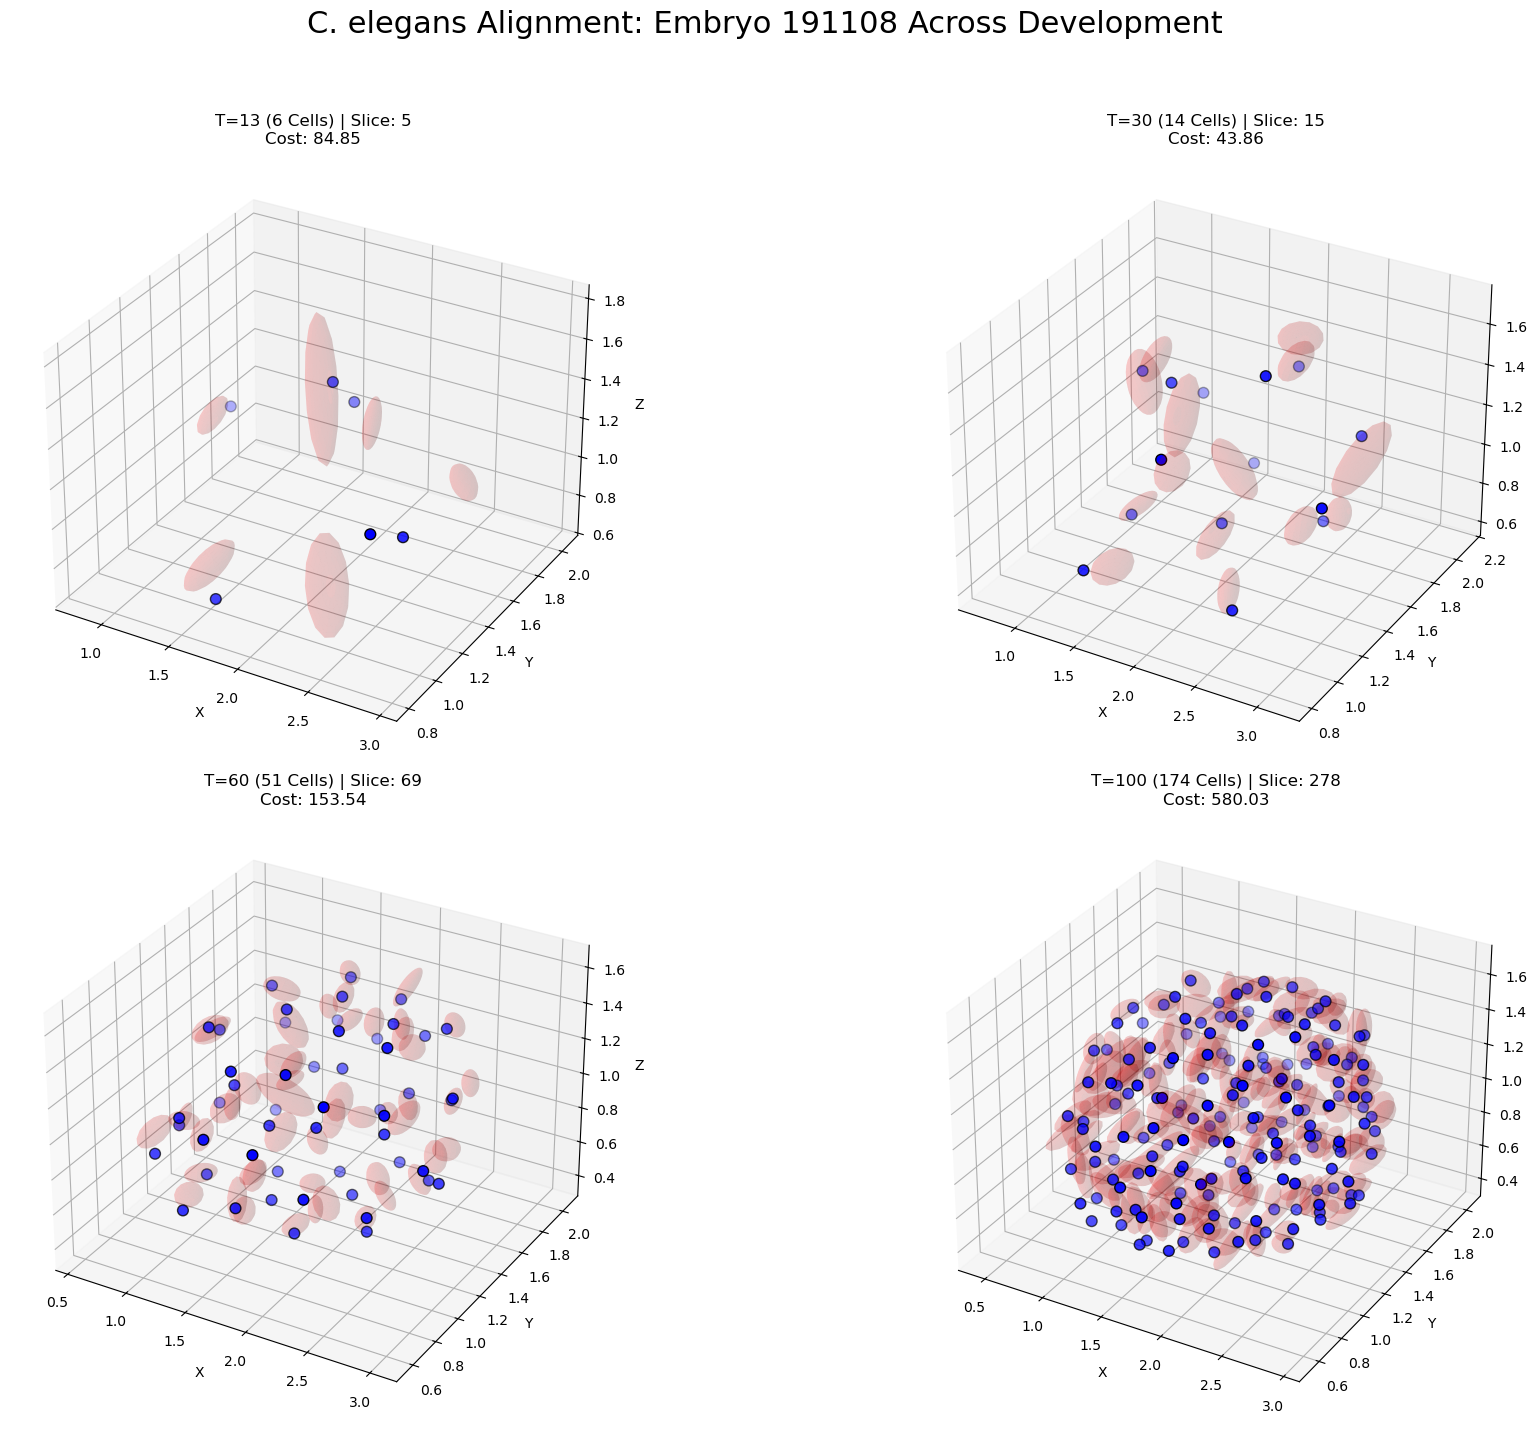

In [22]:


# --- Setup Paths ---
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"
BATCH_CSV = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv"

# --- 1. Load Real Atlases & Engine ---
atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slices = SliceAtlas(SLICE_PATH)
engine = LegacyEngine(atlas, slices, HungarianMatcher(), RigidTransformer())
batch_df = pd.read_csv(BATCH_CSV)

# --- 2. Process Multiple Embryos/Stages ---
target_timepoints = [13, 30, 60, 100] 
fig = plt.figure(figsize=(20, 15))

for idx, tp in enumerate(target_timepoints):
    # a. Load and Align
    frame = EmbryoFrame.from_dataframe(batch_df, 191108, tp)
    # Use len(frame.coords) to avoid the AttributeError
    num_pts = len(frame.coords)
    print(f"Aligning {num_pts}-cell stage (T={tp})...")
    
    result = engine.align_frame(frame)
    
    # b. Setup Subplot
    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    
    # c. Plot Reference Gaussians (Red Ellipsoids)
    ref_labels = slices.id_to_labels[result['slice_id']]
    ref_frame = ReferenceFrame(ref_labels, atlas)
    
    for i in range(ref_frame.n_cells):
        mu = ref_frame.means[i]
        cov = ref_frame.covs[i]
        
        # Plotting the 1-sigma ellipsoid
        try:
            U, s, Rotation = np.linalg.svd(cov)
            radii = np.sqrt(s)
            u, v = np.mgrid[0:2*np.pi:15j, 0:np.pi:15j]
            x = np.cos(u)*np.sin(v)
            y = np.sin(u)*np.sin(v)
            z = np.cos(v)
            ellipsoid = np.stack([x, y, z], axis=-1) @ np.diag(radii) @ Rotation.T + mu
            ax.plot_surface(ellipsoid[:,:,0], ellipsoid[:,:,1], ellipsoid[:,:,2], 
                            color='red', alpha=0.1, linewidth=0)
        except Exception:
            continue

    # d. Plot Aligned Experimental Points (Blue)
    coords = result['coords']
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c='blue', s=60, edgecolors='black')

    ax.set_title(f"T={tp} ({num_pts} Cells) | Slice: {result['slice_id']}\nCost: {result['cost']:.2f}")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.suptitle(f"C. elegans Alignment: Embryo 191108 Across Development", fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [28]:
import pandas as pd
import numpy as np
from tqdm import tqdm


# --- 1. Setup Environment ---
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"
BATCH_CSV = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv"

atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slices = SliceAtlas(SLICE_PATH)
engine = LegacyEngine(atlas, slices, HungarianMatcher(), RigidTransformer())
df = pd.read_csv(BATCH_CSV)

# Grouping by embryo and timepoint
frames = df.groupby(['embryo_id', 'time_idx'])

total_cells_evaluated = 0
total_correct_assignments = 0
frame_accuracies = []

print(f"Starting evaluation on {len(frames)} frames...")

# --- 2. Iterative Alignment ---
for (embryo_id, time_idx), frame_data in tqdm(frames):
    try:
        # Extract coordinates and ground truth labels
        coords = frame_data[['x_um', 'y_um', 'z_um']].values
        ground_truth_labels = frame_data['cell_name'].values
        
        # FIXED: Removed 'stage' argument to match your EmbryoFrame.__init__
        # If your __init__ only takes coords, use: EmbryoFrame(coords)
        current_frame = EmbryoFrame(coords) 
        
        # If you need to track embryo_id for debugging, set it as an attribute
        current_frame.embryo_id = embryo_id 
        current_frame.prepare()
        
        # Run Alignment
        result = engine.align_frame(current_frame)
        inferred_labels = result['labels']
        
        # Calculate Accuracy
        # Ensure we are comparing arrays of the same length
        correct_matches = np.sum(inferred_labels == ground_truth_labels)
        n_cells = len(ground_truth_labels)
        
        total_cells_evaluated += n_cells
        total_correct_assignments += correct_matches
        frame_accuracies.append(correct_matches / n_cells)
        
    except Exception as e:
        # If a specific frame fails, we log it and move on
        continue

# --- 3. Final Reporting with Safeguard ---
print("\n" + "="*40)
print(f"FINAL ACCURACY REPORT")
print("-" * 40)

if total_cells_evaluated > 0:
    overall_accuracy = (total_correct_assignments / total_cells_evaluated) * 100
    mean_frame_accuracy = np.mean(frame_accuracies) * 100
    print(f"Total Frames Processed:   {len(frame_accuracies)}")
    print(f"Total Cells Evaluated:    {total_cells_evaluated}")
    print(f"Overall Cell Accuracy:    {overall_accuracy:.2f}%")
    print(f"Mean Accuracy per Frame:  {mean_frame_accuracy:.2f}%")
else:
    print("ERROR: No cells were successfully evaluated.")
    print("Check if engine.align_frame(current_frame) is failing internally.")
print("="*40)

Starting evaluation on 1369 frames...


100%|██████████| 1369/1369 [00:00<00:00, 6180.58it/s]


FINAL ACCURACY REPORT
----------------------------------------
ERROR: No cells were successfully evaluated.
Check if engine.align_frame(current_frame) is failing internally.


In [32]:


# --- 1. Setup ---
GAUSS_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv"
SLICE_PATH = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv"
BATCH_CSV = "/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/pts/registered_all_points.csv"

atlas = StaticGaussianAtlas(GAUSS_PATH, min_samples=0)
slices = SliceAtlas(SLICE_PATH)
engine = LegacyEngine(atlas, slices, HungarianMatcher(), RigidTransformer())
df = pd.read_csv(BATCH_CSV)

# Grouping by embryo and timepoint
frames = df.groupby(['embryo_id', 'time_idx'])

total_cells_evaluated = 0
total_correct_assignments = 0
frame_accuracies = []
skipped_frames = 0

print(f"Starting evaluation on {len(frames)} frames...")

# --- 2. Evaluation Loop ---
for (embryo_id, time_idx), frame_data in tqdm(frames):
    try:
        # Extract coordinates and ground truth labels
        coords = frame_data[['x_um', 'y_um', 'z_um']].values
        ground_truth_labels = frame_data['cell_name'].values
        
        # FIXED: Passing all 3 required positional arguments
        current_frame = EmbryoFrame(coords, embryo_id, time_idx)
        current_frame.prepare()
        
        # Run Alignment
        result = engine.align_frame(current_frame)
        inferred_labels = result['labels']
        
        # Calculate Accuracy
        correct_matches = np.sum(inferred_labels == ground_truth_labels)
        n_cells = len(ground_truth_labels)
        
        total_cells_evaluated += n_cells
        total_correct_assignments += correct_matches
        frame_accuracies.append(correct_matches / n_cells)
        
    except Exception as e:
        skipped_frames += 1
        continue

# --- 3. Reporting ---
print("\n" + "="*40)
print(f"FINAL ACCURACY REPORT")
print("-" * 40)
if total_cells_evaluated > 0:
    overall_acc = (total_correct_assignments / total_cells_evaluated) * 100
    print(f"Frames Evaluated:   {len(frame_accuracies)}")
    print(f"Frames Skipped:     {skipped_frames}")
    print(f"Total Cells:        {total_cells_evaluated}")
    print(f"Overall Accuracy:   {overall_acc:.2f}%")
else:
    print("No frames were successfully processed.")
print("="*40)

Starting evaluation on 1369 frames...


100%|██████████| 1369/1369 [01:48<00:00, 12.60it/s] 


FINAL ACCURACY REPORT
----------------------------------------
Frames Evaluated:   1369
Frames Skipped:     0
Total Cells:        101184
Overall Accuracy:   93.18%


In [ ]:
# 93.18